In [47]:
# pandas for data manipulation
# re for regular expressions
import re

# pyplot for plotting
# numpy for numerical operations
import numpy as np
import pandas as pd
from scipy.signal import stft
from sklearn.decomposition import PCA

# other .py files
from utils.csv_import_data_analysis import get_csv_files_generalistic, sort_meta_info

In [48]:
# Retrieve CSV files

path_to: str = "C:\\Users\\pedro\\OneDrive - Universidade de Coimbra\\Ambiente de Trabalho\\tese\\thesis-project"
path: str = path_to + "\\new_data"

FileMap = dict[str, dict[str, str]]
csi_map = dict[str, dict[str, dict[str, np.ndarray]]]


data_files = get_csv_files_generalistic(path)
scenarios_id, users_id, activities_id, esps_id = sort_meta_info(path)
print(f"Scenarios: {scenarios_id}")
print(f"Users: {users_id}")
print(f"Activities: {activities_id}")
print(f"ESPs: {esps_id}")
print("\nData files: ", data_files)

Scenarios: ['00', '01']
Users: ['00', '01']
Activities: ['21', '22']
ESPs: ['01', '02', '04', '05', '06', '07']

Data files:  {'scenario_21': {'user_00': {'activity_00': {'esp_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_01_2026-03-04.csv')], 'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_02_2026-03-04.csv')], 'esp_04': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_00_00_04_2026-03-04.csv')]}}, 'user_01': {'activity_01': {'esp_01': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_01_01_01_2026-03-04.csv')], 'esp_02': [WindowsPath('C:/Users/pedro/OneDrive - Universidade de Coimbra/Ambiente de Trabalho/tese/thesis-project/new_data/21_01_01_02_2026-03-04.csv')], 'esp_04': [WindowsPath('

In [49]:
# Per-packet normalization to mitigate AGC effects.
# magnitude shape: (n_samples, n_subcarriers)

# antes de sacar o AGC (5 GHz)
def calibrate_magnitude(magnitude: np.ndarray) -> np.ndarray:
	norm = np.linalg.norm(magnitude, axis=1, keepdims=True)
	norm[norm == 0] = 1  # avoid division by zero
	return magnitude / norm


def apply_pca(magnitude_data, variance_ratio=0.999):
	pca = PCA(n_components=variance_ratio)
	transformed = pca.fit_transform(magnitude_data)
	return transformed, pca


def process_csi(data_file: str, its5ghz: bool) -> np.ndarray:

	file_csv = pd.read_csv(data_file, header=None)

	# number of samples
	if its5ghz:
		print("Com 5 GHz")
		csi_raw: pd.Series = file_csv.iloc[:, 14]
	else:
		csi_raw: pd.Series = file_csv.iloc[:, 25]

	total_sc_2_4_GHz: int = 128
	total_sc_5_GHz: int = 106
	valid_csi: list[list[float]] = []

	# contar CSI inválidos
	no_match_count: int = 0
	no_complete_count: int = 0

	if its5ghz:
		for entry in csi_raw:
			match = re.search(r"\[(.*?)\]", str(entry))
			if not match:
				no_match_count += 1
				continue

			nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

			# para já hard coded, mas para mudar
			if len(nums) in [104, 106]:
				valid_csi.append(nums)
			else:
				no_complete_count += 1

	else:
		for entry in csi_raw:
			match = re.search(r"\[(.*?)\]", str(entry))
			if not match:
				no_match_count += 1
				continue

			nums = [float(n) for n in re.findall(r"-?\d+", match.group(1))]

			if len(nums) == total_sc_2_4_GHz:
				valid_csi.append(nums)
			else:
				no_complete_count += 1

	valid_csi = np.array(valid_csi)

	print(f"Total CSI entries: {len(csi_raw)}")
	print(f"Valid CSI entries: {len(valid_csi)}")
	print(f"Invalid CSI entries (no match): {no_match_count}")
	print(f"Invalid CSI entries (incomplete): {no_complete_count}")
	print("Valid CSI shape: ", valid_csi.shape, "\n")

	# (n_amostras, 128)
	complex_csi = valid_csi[:, ::2] + 1j * valid_csi[:, 1::2]

	# coloca sc DC no centro (index 32)
	fft_csi = np.fft.fftshift(complex_csi, axes=1)

	# Extract the 52 active subcarriers (IEEE 802.11n standard): [6:58]
	# (n_amostras, 52)
	active_sc = fft_csi[:, 6:58]

	# Remove subcarriers at positions 25, 26, 27 (center)
	# (n_amostras, 49)
	active_sc = np.delete(active_sc, [25, 26, 27], axis=1)

	# seleciona sub_carriers: 2 a 47
	active_sc = active_sc[:, 2:48]

	return np.abs(active_sc)


def process_magnitude(data_files: FileMap) -> csi_map:

	magnitudes = {}
	its5ghz = False

	for scenario_key, users_map in data_files.items():
		print(f"Processing scenario: {scenario_key}")
		magnitudes[scenario_key] = {}

		for user_key, activities_map in users_map.items():
			magnitudes[scenario_key][user_key] = {}

			for activity, esps_map in activities_map.items():
				magnitudes[scenario_key][user_key][activity] = {}

				for esp, file_path in esps_map.items():
					if file_path is not None:
						if "22" in scenario_key or "12" in scenario_key:
							print(f"Processing 5GHz data for {scenario_key} | {user_key} | {activity} | {esp}")
							its5ghz = True
						path = file_path[0] if isinstance(file_path, list) else file_path
						magnitudes[scenario_key][user_key][activity][esp] = process_csi(str(path), its5ghz)

	return magnitudes

In [50]:
def compute_pca1_variance(pca_features: np.ndarray) -> float:
	pca1 = pca_features[:, 0]
	return np.var(pca1)


def compute_doppler_energy(pca_features: np.ndarray, fs: float = 1000.0):
	pca1 = pca_features[:, 0]

	# Remove mean (remove static component)
	pca1 = pca1 - np.mean(pca1)

	f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

	# Remove DC component (f=0)
	non_zero_idx = f > 0.1

	energy = np.sum(np.abs(Zxx[non_zero_idx, :])**2)

	return energy


def compute_snr_proxy(pca_features: np.ndarray, fs: float = 1000.0):
	pca1 = pca_features[:, 0]
	pca1 = pca1 - np.mean(pca1)

	f, t, Zxx = stft(pca1, fs=fs, nperseg=256)

	power_spectrum = np.abs(Zxx)**2

	# Static band (near DC)
	static_idx = f < 0.1

	# Dynamic band
	dynamic_idx = (f >= 0.1) & (f <= 10)

	static_power = np.sum(power_spectrum[static_idx, :])
	dynamic_power = np.sum(power_spectrum[dynamic_idx, :])

	if static_power == 0:
		return 0

	return dynamic_power / static_power

In [51]:
magnitude_data = process_magnitude(data_files)

Processing scenario: scenario_21
Total CSI entries: 125
Valid CSI entries: 80
Invalid CSI entries (no match): 45
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (80, 128) 

Total CSI entries: 186
Valid CSI entries: 118
Invalid CSI entries (no match): 68
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (118, 128) 

Total CSI entries: 183
Valid CSI entries: 122
Invalid CSI entries (no match): 61
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (122, 128) 

Total CSI entries: 141
Valid CSI entries: 96
Invalid CSI entries (no match): 45
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (96, 128) 

Total CSI entries: 207
Valid CSI entries: 140
Invalid CSI entries (no match): 67
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (140, 128) 

Total CSI entries: 205
Valid CSI entries: 151
Invalid CSI entries (no match): 54
Invalid CSI entries (incomplete): 0
Valid CSI shape:  (151, 128) 

Processing scenario: scenario_22
Processing 5GHz data for scenario_22 | user_00 | a

In [52]:
# define sampling frequency (Hz) as
# the original packet rate/s
fs = 1000

# Compute metrics for each individual CSI file
metrics_per_file = {}

scenarios = {
	"11": "Cenário 1 - 2.4 GHz",
	"12": "Cenário 1 - 5 GHz",
	"21": "Cenário 2 - 2.4 GHz",
	"22": "Cenário 2 - 5 GHz",
}

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, features in esps_map.items():
				label = f"{user_key}-{activity}-{place}-{esp}"
				metrics_per_file[label] = {
					"PCA1 Variance": compute_pca1_variance(features),
					"Doppler Energy": compute_doppler_energy(features, fs),
					"SNR Proxy": compute_snr_proxy(features, fs),
				}

print(f"Computed metrics for {len(metrics_per_file)} files")


Computed metrics for 12 files


c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 80, using nperseg = 80
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 118, using nperseg = 118
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 122, using nperseg = 122
  freqs, time, Zxx = _spectral_helper(x, x, fs, window, nperseg, noverlap,
c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\scipy\signal\_spectral_py.py:1595: UserWarning: nperseg = 256 is greater than input length  = 96, using nperseg = 96
  freqs, ti

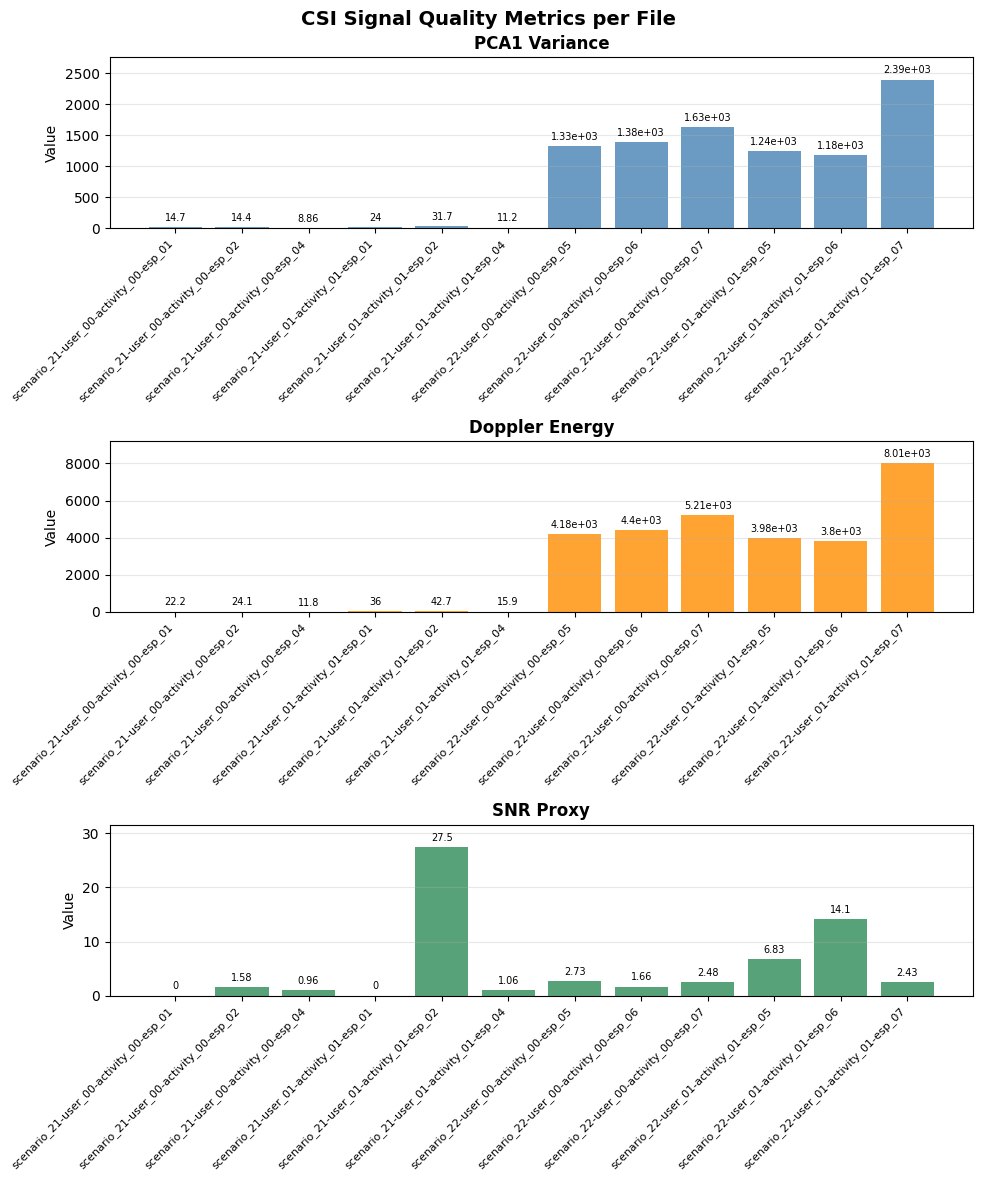

In [53]:
metric_names = ["PCA1 Variance", "Doppler Energy", "SNR Proxy"]
colors = ["steelblue", "darkorange", "seagreen"]
labels = list(metrics_per_file.keys())
x = np.arange(len(labels))

from matplotlib import pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(max(10, len(labels) * 0.8), 12))

for ax, metric, color in zip(axes, metric_names, colors):
	values = [metrics_per_file[lbl][metric] for lbl in labels]
	bars = ax.bar(x, values, color=color, alpha=0.8)
	ax.bar_label(bars, fmt="%.3g", padding=3, fontsize=7)
	ax.set_title(metric, fontsize=12, fontweight="bold")
	ax.set_ylabel("Value")
	ax.set_xticks(x)
	ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)
	ax.grid(axis="y", alpha=0.3)
	ax.margins(y=0.15)

fig.suptitle("CSI Signal Quality Metrics per File", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


#### CSI Magnitude vs Number of Packages analysis

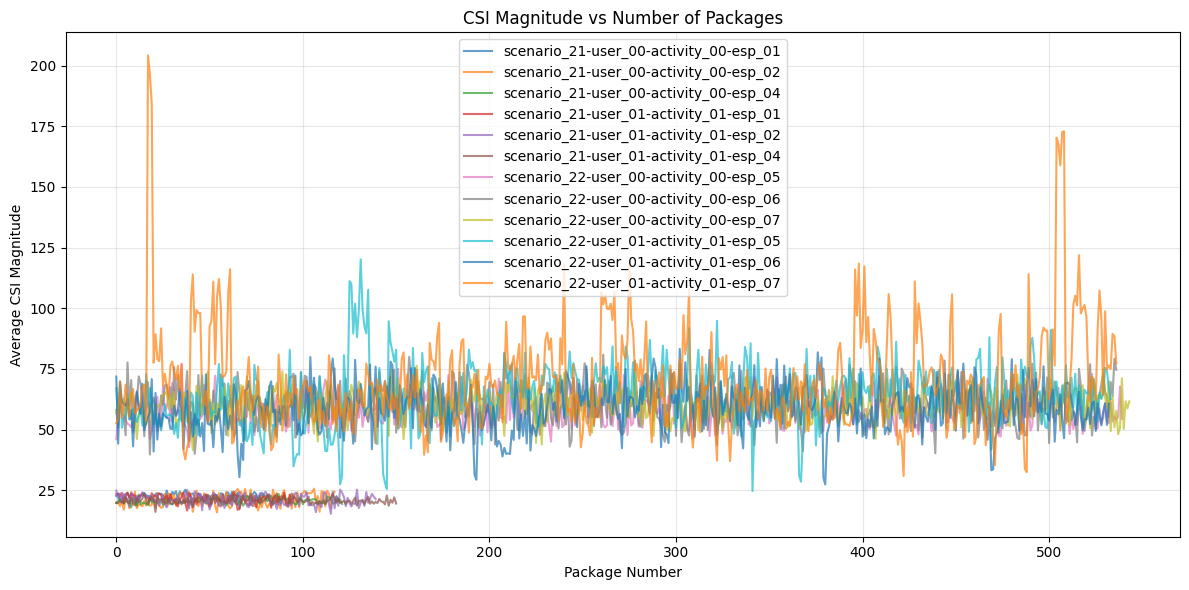

In [54]:
plt.figure(figsize=(12, 6))

for user_key, activities_map in magnitude_data.items():
	for activity, places_map in activities_map.items():
		for place, esps_map in places_map.items():
			for esp, csi_magnitude in esps_map.items():
				# Calculate average magnitude across all subcarriers for each packet
				avg_magnitude = csi_magnitude.mean(axis=1)
				n_packets = len(avg_magnitude)

				plt.plot(range(n_packets), avg_magnitude, label=f'{user_key}-{activity}-{place}-{esp}', alpha=0.7)

plt.xlabel('Package Number')
plt.ylabel('Average CSI Magnitude')
plt.title('CSI Magnitude vs Number of Packages')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Dataset

In [55]:
# função retirada do pipeline da Diana
def segment_signal(
	signal: np.ndarray, window_size: int, overlap: int,
) -> list[np.ndarray]:
	segments: list[np.ndarray] = []

	for i in range(0, signal.shape[0], overlap):
		if i + window_size < signal.shape[0]:
			segment = signal[i : i + window_size]
			segments.append(segment)

	return segments


def process_pipeline(csi_magnitude: np.ndarray) -> np.ndarray:

	print("Original CSI magnitude shape:", csi_magnitude.shape)
	csi_magnitude = calibrate_magnitude(csi_magnitude)

	print("Calibrated CSI magnitude shape:", csi_magnitude.shape)
	pca_features, _ = apply_pca(csi_magnitude, variance_ratio=0.999)

	# parâmetros de segmentação
	window_size: int = 10
	overlap_size: int = 2

	print("PCA features shape:", pca_features.shape)

	segmented_data = segment_signal(pca_features, window_size, overlap_size)
	segmented_data = np.array(segmented_data)

	print("segmented data shape:", segmented_data.shape)

	# obtemos 3 matrizes de features: mean e std
	features = [
		np.var(segmented_data[:, :, 0], axis=1),
		np.std(segmented_data[:, :, 0], axis=1),
		np.sum(segmented_data[:, :, 0] ** 2, axis=1),
	]
	features = np.array(features)

	print("features shape (3, n_segments):", features.shape)

	df_x = np.transpose(features)

	print("features transposed shape:", df_x.shape, "\n")

	return df_x


def build_scenario_dataset(
	users_map: dict[str, dict[str, dict[str, np.ndarray]]],
	scenario_key: str,
	expected_users: int = 2,
	expected_activities: int = 2,
	expected_esps: int = 3,
) -> pd.DataFrame:
	rows: list[dict[str, object]] = []

	for user_key, activities_map in users_map.items():
		for activity_key, esps_map in activities_map.items():
			for esp_key, csi in esps_map.items():

				print("Processing: ", scenario_key, "|", user_key, "|", activity_key, "|", esp_key)
				window_features = process_pipeline(csi)

				for feature_vector in window_features:
					rows.append(
						{
							"scenario": scenario_key,
							"user": user_key,
							"activity": activity_key,
							"esp": esp_key,
							"variance": feature_vector[0],
							"std": feature_vector[1],
							"energy": feature_vector[2],
						},
					)

	scenario_df = pd.DataFrame(rows)

	users_found = scenario_df["user"].nunique() if not scenario_df.empty else 0
	activities_found = scenario_df["activity"].nunique() if not scenario_df.empty else 0
	esps_found = scenario_df["esp"].nunique() if not scenario_df.empty else 0

	if users_found != expected_users or activities_found != expected_activities or esps_found != expected_esps:
		print(
			f"[WARN] Scenario {scenario_key}: users={users_found}/{expected_users}, "
			f"activities={activities_found}/{expected_activities}, esps={esps_found}/{expected_esps}",
		)

	# Add label column: activity "00" -> 0, activity "01" -> 1
	activity_to_label = {
		"activity_00": 0,
		"activity_01": 1,
	}
	scenario_df["label"] = scenario_df["activity"].map(activity_to_label)

	# Keep only feature columns and label
	scenario_df = scenario_df[["variance", "std", "energy", "label"]]

	return scenario_df

In [56]:
# Dataset per scenario
dataset_per_scenario: dict[str, pd.DataFrame] = {}

for scenario_key, users_map in magnitude_data.items():
	print(f"Building dataset for scenario {scenario_key}\n")
	scenario_df = build_scenario_dataset(users_map, scenario_key)
	dataset_per_scenario[scenario_key] = scenario_df
	print(f"Scenario {scenario_key}: {scenario_df.shape[0]} windows (features + labels)")

scenario_keys = sorted(dataset_per_scenario.keys())

if len(scenario_keys) != 4:
	print(f"\n[WARN] Expected 4 scenarios, found {len(scenario_keys)}: {scenario_keys}")

# Create explicit variables for up to 4 scenarios found in the data
dataset_1 = dataset_per_scenario[scenario_keys[0]] if len(scenario_keys) > 0 else pd.DataFrame()
dataset_2 = dataset_per_scenario[scenario_keys[1]] if len(scenario_keys) > 1 else pd.DataFrame()
dataset_3 = dataset_per_scenario[scenario_keys[2]] if len(scenario_keys) > 2 else pd.DataFrame()
dataset_4 = dataset_per_scenario[scenario_keys[3]] if len(scenario_keys) > 3 else pd.DataFrame()

print("\nCreated scenario datasets:")
for i, key in enumerate(scenario_keys[:4], start=1):
	print(f"- dataset_{i} -> scenario '{key}'")

Building dataset for scenario scenario_21

Processing:  scenario_21 | user_00 | activity_00 | esp_01
Original CSI magnitude shape: (80, 46)
Calibrated CSI magnitude shape: (80, 46)
PCA features shape: (80, 33)
segmented data shape: (35, 10, 33)
features shape (3, n_segments): (3, 35)
features transposed shape: (35, 3) 

Processing:  scenario_21 | user_00 | activity_00 | esp_02
Original CSI magnitude shape: (118, 46)
Calibrated CSI magnitude shape: (118, 46)
PCA features shape: (118, 33)
segmented data shape: (54, 10, 33)
features shape (3, n_segments): (3, 54)
features transposed shape: (54, 3) 

Processing:  scenario_21 | user_00 | activity_00 | esp_04
Original CSI magnitude shape: (122, 46)
Calibrated CSI magnitude shape: (122, 46)
PCA features shape: (122, 35)
segmented data shape: (56, 10, 35)
features shape (3, n_segments): (3, 56)
features transposed shape: (56, 3) 

Processing:  scenario_21 | user_01 | activity_01 | esp_01
Original CSI magnitude shape: (96, 46)
Calibrated CSI ma

In [57]:
for dataset in [dataset_1, dataset_2, dataset_3, dataset_4]:
	if dataset.empty:
		print("\n[WARN] One of the datasets is empty. Check scenario keys and data processing.")
		continue
	print("Dataset structure (first 5 rows):")
	print(dataset.head())
	print(f"\nDataset shape: {dataset.shape}")
	print(f"Columns: {dataset.columns.tolist()}")
	print(f"Label values: {dataset['label'].unique()}")

Dataset structure (first 5 rows):
   variance       std    energy  label
0  0.011643  0.107901  0.121234      0
1  0.014451  0.120212  0.147351      0
2  0.013820  0.117559  0.152052      0
3  0.015399  0.124094  0.154315      0
4  0.014810  0.121698  0.151428      0

Dataset shape: (324, 4)
Columns: ['variance', 'std', 'energy', 'label']
Label values: [0 1]
Dataset structure (first 5 rows):
   variance       std    energy  label
0  0.061071  0.247125  0.679167      0
1  0.040672  0.201673  0.541864      0
2  0.043133  0.207685  0.557045      0
3  0.048780  0.220861  0.540729      0
4  0.038584  0.196429  0.401568      0

Dataset shape: (1584, 4)
Columns: ['variance', 'std', 'energy', 'label']
Label values: [0 1]

[WARN] One of the datasets is empty. Check scenario keys and data processing.

[WARN] One of the datasets is empty. Check scenario keys and data processing.


In [58]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

model_results = {}

for scenario_key, dataset in dataset_per_scenario.items():
	if dataset.empty:
		print(f"[SKIP] {scenario_key}: empty dataset")
		continue

	if dataset["label"].nunique() < 2:
		print(f"[SKIP] {scenario_key}: only one label present")
		continue

	X = dataset[["variance", "std", "energy"]]
	y = dataset["label"]

	X_train, X_test, y_train, y_test = train_test_split(
		X, y, test_size=0.2, random_state=42, stratify=y
	)

	models = {
		"SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)),
		"RF": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
	}

	model_results[scenario_key] = {}

	print(f"\n=== Scenario: {scenario_key} ===")
	for model_name, model in models.items():
		model.fit(X_train, y_train)
		y_pred = model.predict(X_test)

		acc = accuracy_score(y_test, y_pred)
		f1_macro = f1_score(y_test, y_pred, average="macro")

		model_results[scenario_key][model_name] = {
			"accuracy": acc,
			"f1_macro": f1_macro,
			"report": classification_report(y_test, y_pred, output_dict=True),
		}

		print(f"\n{model_name}")
		print(f"Accuracy: {acc:.4f}")
		print(f"F1-macro: {f1_macro:.4f}")
		print(classification_report(y_test, y_pred, digits=4))


=== Scenario: scenario_21 ===

SVM
Accuracy: 0.6000
F1-macro: 0.5999
              precision    recall  f1-score   support

           0     0.5429    0.6552    0.5938        29
           1     0.6667    0.5556    0.6061        36

    accuracy                         0.6000        65
   macro avg     0.6048    0.6054    0.5999        65
weighted avg     0.6114    0.6000    0.6006        65




RF
Accuracy: 0.7692
F1-macro: 0.7684
              precision    recall  f1-score   support

           0     0.7188    0.7931    0.7541        29
           1     0.8182    0.7500    0.7826        36

    accuracy                         0.7692        65
   macro avg     0.7685    0.7716    0.7684        65
weighted avg     0.7738    0.7692    0.7699        65


=== Scenario: scenario_22 ===

SVM
Accuracy: 0.8707
F1-macro: 0.8696
              precision    recall  f1-score   support

           0     0.8172    0.9560    0.8812       159
           1     0.9466    0.7848    0.8581       158

    accuracy                         0.8707       317
   macro avg     0.8819    0.8704    0.8696       317
weighted avg     0.8817    0.8707    0.8697       317


RF
Accuracy: 0.8454
F1-macro: 0.8453
              precision    recall  f1-score   support

           0     0.8313    0.8679    0.8492       159
           1     0.8609    0.8228    0.8414       158

    accuracy                        